Si consideri il dataset clinico SUPPORT2, contenente informazioni demografiche, fisiologiche e di laboratorio relativa ai pazienti ospedalizzati. Dopo aver caricato i dati, rimuovere le variabili di outcome e prognosi per evitare fenomeni di data leakage e selezionare una variabile target (ad esempio dzgroup)

In [13]:
import pandas as pd
df = pd.read_csv("./dataset_esercitazione.csv",sep=',')
print(df)

           age     sex            dzgroup             dzclass  num.co   edu  \
0     62.84998    male        Lung Cancer              Cancer       0  11.0   
1     60.33899  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
2     52.74698  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
3     42.38498  female        Lung Cancer              Cancer       2  11.0   
4     79.88495  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   
...        ...     ...                ...                 ...     ...   ...   
9100  66.07300    male  ARF/MOSF w/Sepsis            ARF/MOSF       1   8.0   
9101  55.15399  female               Coma                Coma       1  11.0   
9102  70.38196    male  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   
9103  47.01999    male       MOSF w/Malig            ARF/MOSF       1  13.0   
9104  81.53894  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   8.0   

          income  scoma  charges      totcst  ...  

Dopo aver caricato i dati, rimuovere le variabili di outcome e prognosi per 
evitare fenomeni di data leakage e selezionare una variabile target (ad esempio dzgroup).
Suddividere il dataset in training set (95%) e test set (5%) utilizzando un campionamento stratificato rispetto 
alla variabile target («death»), in modo da preservare la distribuzione delle classi.

In [4]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=['dzgroup', 'dzclass', 'death', 'surv2m', 'surv6m', 'prg2m', 'prg6m', 'hday', 'charges', 'totcst', 'totmcst', 'avtisst', 'dnr', 'dnrday'])
y=df['death']
X_tr, X_te, y_tr, y_te=train_test_split(X,y,test_size=0.05,stratify=y) 

Gestire i dati mancanti applicando imputazione con mediana per le variabili numeriche e con un valore 
costante (ad esempio "Unknown") per quelle categoriche; successivamente codificare le variabili categoriche tramite Ordinal Encoding

In [5]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

numeric_features = X_tr.select_dtypes(include=['number']).columns.tolist()
categorical_features = [col for col in X_tr.columns if col not in numeric_features]

report_mancanti = (X_tr.isnull().sum() / len(X_tr)) * 100 #Checking dei valori mancanti in percentuale

# Usiamo Pandas per estrarre direttamente una lista con i nomi delle sole colonne da imputare
colonne_con_nan = report_mancanti[report_mancanti > 0].index.tolist()

print(f"Colonne totali con dati mancanti: {len(colonne_con_nan)}")

# Dividiamo queste colonne "problematiche" in numeriche e categoriche
nan_numeriche = [col for col in colonne_con_nan if col in numeric_features]
nan_categoriche = [col for col in colonne_con_nan if col in categorical_features]


# Imputiamo SOLO le colonne numeriche che ne hanno bisogno
if len(nan_numeriche) > 0:
    imputer_num = SimpleImputer(strategy='median')
    imputer_num.set_output(transform='pandas')
    
    # Applichiamo solo al sotto-dataset delle colonne bucate
    X_tr[nan_numeriche] = imputer_num.fit_transform(X_tr[nan_numeriche])
    X_te[nan_numeriche] = imputer_num.transform(X_te[nan_numeriche])

# Imputiamo SOLO le colonne categoriche che ne hanno bisogno
if len(nan_categoriche) > 0:
    imputer_cat = SimpleImputer(strategy='constant', fill_value='Unknown')
    imputer_cat.set_output(transform='pandas')
    
    # Applichiamo solo al sotto-dataset delle colonne bucate
    X_tr[nan_categoriche] = imputer_cat.fit_transform(X_tr[nan_categoriche])
    X_te[nan_categoriche] = imputer_cat.transform(X_te[nan_categoriche])

# ==========================================
# 4. ENCODING
# ==========================================
# L'encoding invece va fatto sempre su TUTTE le categoriche, che avessero NaN o meno
if len(categorical_features) > 0:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-7)
    encoder.set_output(transform='pandas')
    
    X_tr[categorical_features] = encoder.fit_transform(X_tr[categorical_features])
    X_te[categorical_features] = encoder.transform(X_te[categorical_features])


Colonne totali con dati mancanti: 22


Applicare lo scaling delle feature numeriche tramite z-scoring, quindi calcolare e analizzare la matrice di correlazione, individuando eventuali coppie di variabili altamente correlate e discutendo la presenza di multicollinearità.

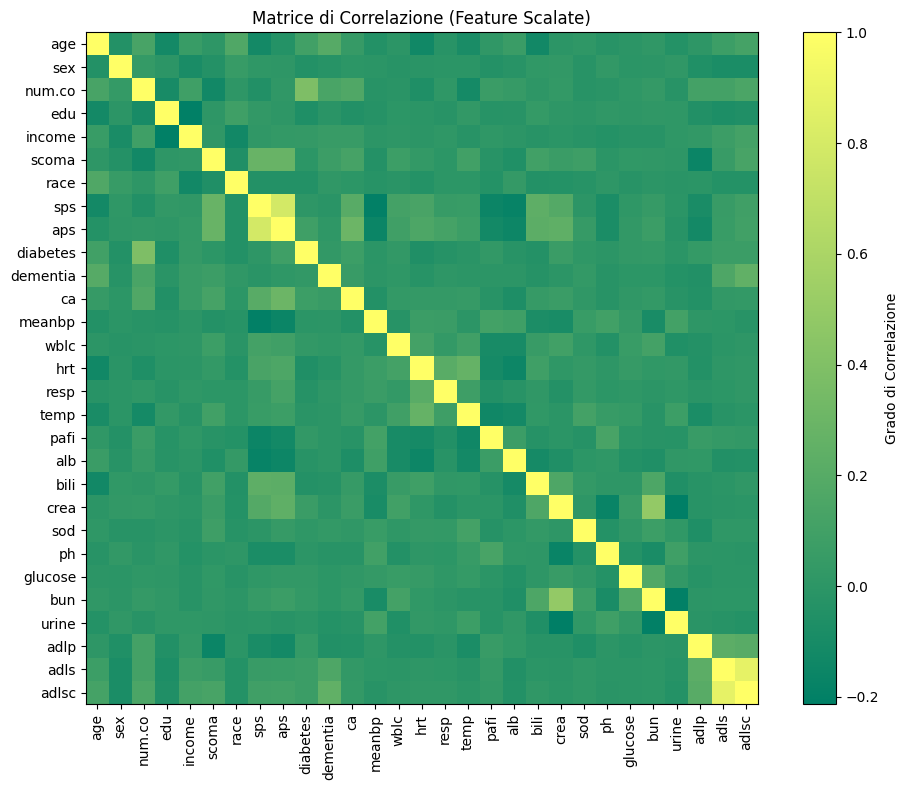

Coppie con correlazione elevata (> 0.8):
adlsc  adls    0.879722
dtype: float64


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import numpy as np
#Scaling
scaler = StandardScaler()

X_tr_scaler = X_tr.copy()
X_tr_scaler[X_tr.columns] = scaler.fit_transform(X_tr)

X_te_scaler = X_te.copy()
X_te_scaler[X_te.columns] = scaler.transform(X_te)

#Calcolo della matrice di correlazione
corr_matrix = X_tr_scaler.corr()

#Visualizzazione grafica
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap= 'summer', interpolation='nearest')
plt.colorbar(label = 'Grado di Correlazione')

#Nomi delle colonne sugli assi
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Matrice di Correlazione (Feature Scalate)")
plt.tight_layout()
plt.show()

# Individuazione automatica delle coppie altamente correlate (> 0.8)
# Creiamo una maschera per guardare solo la parte superiore della matrice (evita i duplicati)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) #Serve a selezionare solo la metà superiore di una matrice, "oscurando" (mettendo a zero o a NaN) la parte inferiore.
                                                                                 #Una matrice di correlazione è speculare (o simmetrica).
                                                                                 #Usiamo triu per pulire i duplicati e non leggere due volte la stessa informazione. 
                                                                                 #È come guardare solo la metà di un foglio piegato a metà sapendo che l'altra parte è identica.
coppie_alte = upper.unstack().dropna()
coppie_alte = coppie_alte[abs(coppie_alte) > 0.8].sort_values(ascending=False)
        #La MULTICOLLINEARITÀ viene trattata come un problema di ridondanza informativa e descrive una relazione troppo stretta tra due o più variabili indipendenti.
        #Descrive una situazione in cui due variabili non sono solo "correlate", ma sono quasi interscambiabili.
print("Coppie con correlazione elevata (> 0.8):")
if not coppie_alte.empty:
    print(coppie_alte)
else:
    print("Nessuna coppia trovata sopra la soglia 0.8")



Gestire la multicollinearità mediante rimozione di feature ridondanti o tramite una trasformazione lineare (ad
esempio PCA), e infine applicare un metodo di selezione delle feature per identificare le variabili più rilevanti,
commentando criticamente i risultati ottenuti.

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif

#Gestisco la multicollinearità rimuovendo la variabile adls
X_tr_clean = X_tr_scaler.drop(columns=['adls'])
X_te_clean = X_te_scaler.drop(columns=['adls'])
'''
#Per evitare che SKbest vadi in crash riempio i buchi con le medie
X_tr_clean = X_tr_clean.fillna(X_tr_clean.median())
X_te_clean = X_te_clean.fillna(X_tr_clean.median())
'''

# --- 2. RETE DI SICUREZZA TOTALE ---
# Invece della mediana (che salta le categoriche), usiamo un valore fittizio 
# o il valore più frequente per tappare TUTTO indiscriminatamente.
# Il metodo bfill (backward fill) o ffill (forward fill) copre i buchi 
# copiando il valore della riga precedente/successiva.
X_tr_clean = X_tr_clean.ffill().bfill()
X_te_clean = X_te_clean.ffill().bfill()

#Addestro il selettore sui dati puliti e sul target "death"
selector = SelectKBest(score_func=f_classif, k=10)
X_tr_sel = selector.fit_transform(X_tr_clean, y_tr)
X_te_sel = selector.transform(X_te_clean)

#Stampa feature
selected_features = X_tr_clean.columns[selector.get_support()].tolist()
print(f"Le feature più importanti sono: {selected_features}")

Le feature più importanti sono: ['age', 'sex', 'num.co', 'scoma', 'sps', 'aps', 'dementia', 'ca', 'meanbp', 'adlsc']


Implementare un clustering dei punti del data set processato nelle fasi precedenti, utilizzando l’algoritmo
DBSCAN con una griglia di ricerca degli iper-parametri:
MinPts = 5, 10, 20
Eps = 0.5, 1.5, 2.0
Stampare l’accuracy del modello di clustering sul training set e sul test set. Valuta la purezza del clustering.

In [9]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import accuracy_score
from sklearn.metrics.cluster import contingency_matrix
import numpy as np
import pandas as pd

#1. Griglia di ricerca
eps_values = [0.5, 1.5, 2.0]
min_pts_values = [5, 10, 20]

#2. Funzione per la valutazione
def valuta_dbscan(X, y_true, eps_val, min_pts_val, nome_set):
    #Si inizializza il DBSCAN
    db = DBSCAN(eps = eps_val, min_samples = min_pts_val)
    #Applichiamo il fit_predict 
    cluster_labels = db.fit_predict(X)
    #Calcoliamo quanti cluster utili e quanto rumore c'è 
    n_cluster = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)

    #Se crea 0 cluster (solo rumore), ti fermi
    if n_cluster == 0:
        print(f"[{nome_set}] Eps={eps_val}, MinPts={min_pts_val} -> Modello fallito (0 Cluster, {n_noise} punti di Rumore)")
    #Calcolo purezza
    mat = contingency_matrix(y_true, cluster_labels)
    purezza = np.sum(np.amax(mat, axis = 0))/ np.sum(mat)

    #Calcolo ACCURACY
    y_pred = np.zeros_like(cluster_labels)

    for cluster in set(cluster_labels):
        mask = (cluster_labels == cluster)
        data_in_cluster = y_true[mask]

        if len(data_in_cluster) > 0:
            # Trucco Pandas: .value_counts().idxmax() prende l'etichetta vera più frequente
            classe_maggioritaria = pd.Series(data_in_cluster).value_counts().idxmax()
            y_pred[mask] = classe_maggioritaria
            
    accuracy = accuracy_score(y_true, y_pred)
    
    print(f"[{nome_set}] Eps={eps_val}, MinPts={min_pts_val} | Cluster: {n_cluster}, Rumore: {n_noise} | Purezza: {purezza:.2%} | Accuracy: {accuracy:.2%}")

# 3. Esecuzione della griglia (i 9 tentativi)
print("=== INIZIO RICERCA PARAMETRI DBSCAN ===\n")
for e in eps_values:
    for m in min_pts_values:
        valuta_dbscan(X_tr_clean, y_tr, e, m, "TRAIN")
        valuta_dbscan(X_te_clean, y_te, e, m, "TEST ")
        print("-" * 80)


=== INIZIO RICERCA PARAMETRI DBSCAN ===

[TRAIN] Eps=0.5, MinPts=5 -> Modello fallito (0 Cluster, 8649 punti di Rumore)
[TRAIN] Eps=0.5, MinPts=5 | Cluster: 0, Rumore: 8649 | Purezza: 68.10% | Accuracy: 68.10%
[TEST ] Eps=0.5, MinPts=5 -> Modello fallito (0 Cluster, 456 punti di Rumore)
[TEST ] Eps=0.5, MinPts=5 | Cluster: 0, Rumore: 456 | Purezza: 68.20% | Accuracy: 68.20%
--------------------------------------------------------------------------------
[TRAIN] Eps=0.5, MinPts=10 -> Modello fallito (0 Cluster, 8649 punti di Rumore)
[TRAIN] Eps=0.5, MinPts=10 | Cluster: 0, Rumore: 8649 | Purezza: 68.10% | Accuracy: 68.10%
[TEST ] Eps=0.5, MinPts=10 -> Modello fallito (0 Cluster, 456 punti di Rumore)
[TEST ] Eps=0.5, MinPts=10 | Cluster: 0, Rumore: 456 | Purezza: 68.20% | Accuracy: 68.20%
--------------------------------------------------------------------------------
[TRAIN] Eps=0.5, MinPts=20 -> Modello fallito (0 Cluster, 8649 punti di Rumore)
[TRAIN] Eps=0.5, MinPts=20 | Cluster: 0, 

Implementare un clustering dei punti del dataset processato nelle fasi precedenti, utilizzando un secondo
algoritmo di clustering. La selezione dell’algoritmo deve essere coerente con la natura del dato. Valuta la
purezza del clustering.

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import contingency_matrix
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# 1. Inizializziamo il K-Means
# Scegliamo n_clusters=2 perché vogliamo confrontarlo con le 2 classi di 'death'
# n_init=10 è lo standard consigliato dalle slide del professore
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)

# 2. Addestriamo il modello sul Training Set (calcola i centroidi e assegna le etichette)
labels_tr = kmeans.fit_predict(X_tr_clean)

# 3. Applichiamo il modello sul Test Set (K-Means ha il predict!)
labels_te = kmeans.predict(X_te_clean)

# 4. Funzione di valutazione (Purezza e Accuracy)
def valuta_kmeans(y_true, cluster_labels, nome_set):
    # -- Calcolo PUREZZA --
    matrice = contingency_matrix(y_true, cluster_labels)
    purezza = np.sum(np.amax(matrice, axis=0)) / np.sum(matrice)
    
    # -- Calcolo ACCURACY "Terra-Terra" (Mapping delle etichette) --
    y_pred = np.zeros_like(cluster_labels)
    
    for cluster in set(cluster_labels):
        maschera = (cluster_labels == cluster)
        dati_reali = y_true[maschera]
        
        if len(dati_reali) > 0:
            # Troviamo la classe vera più frequente in questo cluster
            classe_maggioritaria = pd.Series(dati_reali).value_counts().idxmax()
            y_pred[maschera] = classe_maggioritaria
            
    accuracy = accuracy_score(y_true, y_pred)
    
    print(f"[{nome_set}] K-Means (k=2) | Purezza: {purezza:.2%} | Accuracy: {accuracy:.2%}")

print("=== RISULTATI CLUSTERING K-MEANS ===")
valuta_kmeans(y_tr, labels_tr, "TRAIN")
valuta_kmeans(y_te, labels_te, "TEST ")

=== RISULTATI CLUSTERING K-MEANS ===
[TRAIN] K-Means (k=2) | Purezza: 68.10% | Accuracy: 68.10%
[TEST ] K-Means (k=2) | Purezza: 68.20% | Accuracy: 68.20%


Esegui la comparazione delle performance utilizzando l’etichetta «death» con criteri di valutazione esterni.

In [11]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, completeness_score, v_measure_score
import pandas as pd

# 1. Riapplichiamo i modelli sul Training Set per la comparazione
# K-Means
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X_tr_clean)

# DBSCAN (Usiamo eps=2.0, min_samples=20 dalla tua grid search precedente)
dbscan = DBSCAN(eps=2.0, min_samples=20)
labels_dbscan = dbscan.fit_predict(X_tr_clean)

# 2. Creiamo una funzione per estrarre tutte le metriche esterne richieste
def calcola_metriche_esterne(y_true, labels, nome_modello):
    return {
        "Algoritmo": nome_modello,
        "ARI (Adjusted Rand)": adjusted_rand_score(y_true, labels),
        "NMI (Mutual Info)": normalized_mutual_info_score(y_true, labels),
        "Homogeneity": homogeneity_score(y_true, labels),
        "Completeness": completeness_score(y_true, labels),
        "V-Measure": v_measure_score(y_true, labels)
    }

# 3. Raccogliamo i risultati
risultati = [
    calcola_metriche_esterne(y_tr, labels_kmeans, "K-Means (k=2)"),
    calcola_metriche_esterne(y_tr, labels_dbscan, "DBSCAN (eps=2.0, MinPts=20)")
]

# 4. Stampiamo in formato Tabella (Dataframe Pandas) per una facile lettura
df_comparazione = pd.DataFrame(risultati)
print("=== COMPARAZIONE PERFORMANCE CLUSTERING (Target: 'death') ===\n")
display(df_comparazione)

=== COMPARAZIONE PERFORMANCE CLUSTERING (Target: 'death') ===



,Algoritmo,ARI (Adjusted Rand),NMI (Mutual Info),Homogeneity,Completeness,V-Measure
0,K-Means (k=2),-0.014382,0.008174,0.008221,0.008128,0.008174
1,"DBSCAN (eps=2.0, MinPts=20)",-0.014508,0.009263,0.005414,0.032044,0.009263
